# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
    https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
DATA_PATH = "../dataset/weatherAUS.csv"
df_raw = pd.read_csv(DATA_PATH)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# Statistik numerik dan kategorikal
df_raw.describe().T.style.background_gradient(cmap="Blues")
df_raw.describe(include="object")

/tmp/ipykernel_114124/715510950.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object")


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


In [4]:
# Hitung missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count"  : missing,
    "Missing (%)"    : missing_pct
}).sort_values("Missing (%)", ascending=False)

missing_df = missing_df[missing_df["Missing Count"] > 0]
print(f"Kolom dengan missing values: {len(missing_df)}")
missing_df

Kolom dengan missing values: 21


,Missing Count,Missing (%)
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


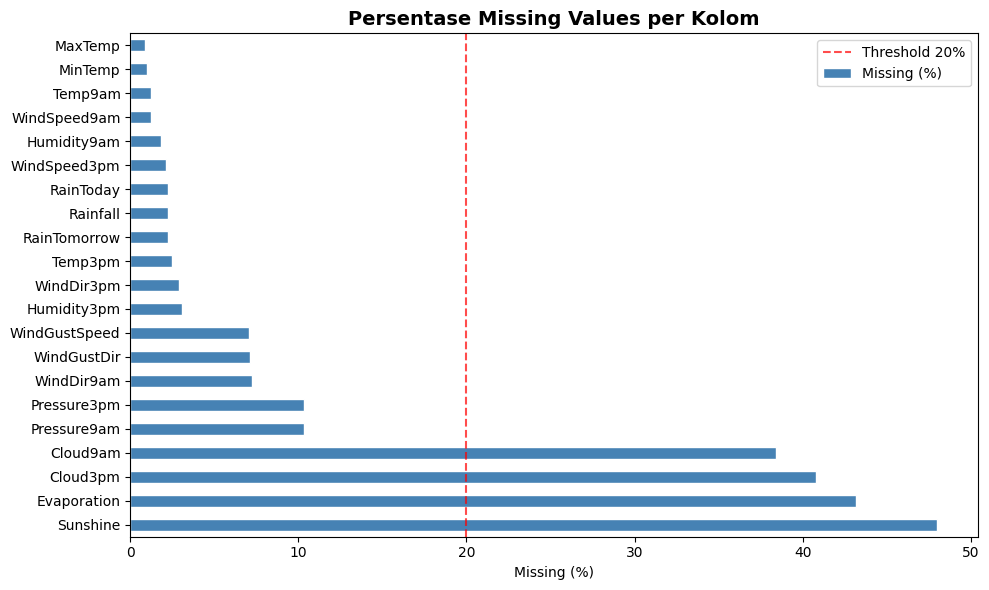

In [5]:
# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_df["Missing (%)"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Persentase Missing Values per Kolom", fontsize=14, fontweight="bold")
ax.set_xlabel("Missing (%)")
ax.axvline(x=20, color="red", linestyle="--", alpha=0.7, label="Threshold 20%")
ax.legend()
plt.tight_layout()
plt.show()

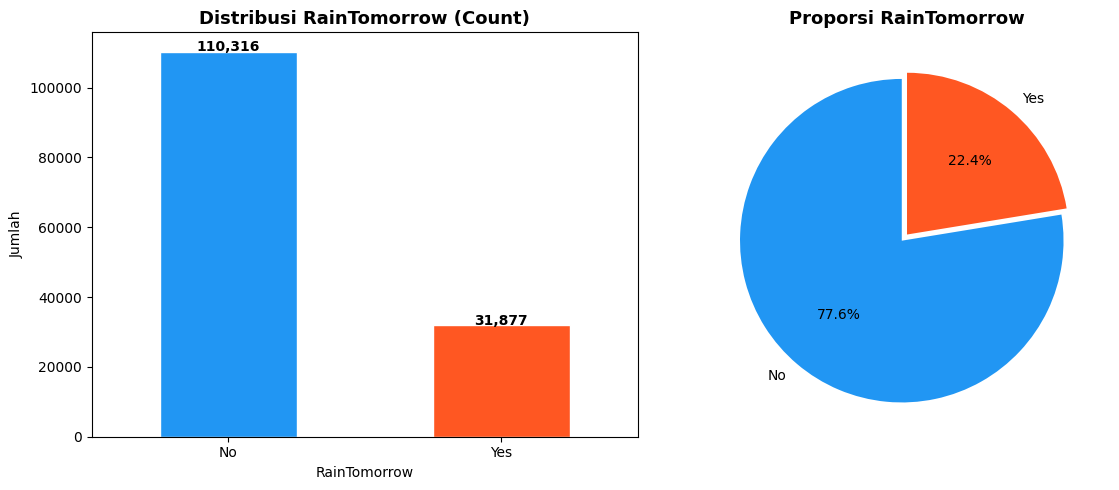


Distribusi Target:
  No  : 110,316 (75.8%)
  Yes : 31,877 (21.9%)


In [6]:
# Distribusi kelas target
target_counts = df_raw["RainTomorrow"].value_counts()
target_pct    = df_raw["RainTomorrow"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
target_counts.plot(kind="bar", ax=axes[0],
                   color=["#2196F3", "#FF5722"], edgecolor="white", rot=0)
axes[0].set_title("Distribusi RainTomorrow (Count)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("RainTomorrow")
axes[0].set_ylabel("Jumlah")
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index,
            autopct="%1.1f%%", colors=["#2196F3", "#FF5722"],
            startangle=90, explode=(0.05, 0))
axes[1].set_title("Proporsi RainTomorrow", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nDistribusi Target:")
for label, count in target_counts.items():
    print(f"  {label:3s} : {count:6,} ({count/len(df_raw)*100:.1f}%)")

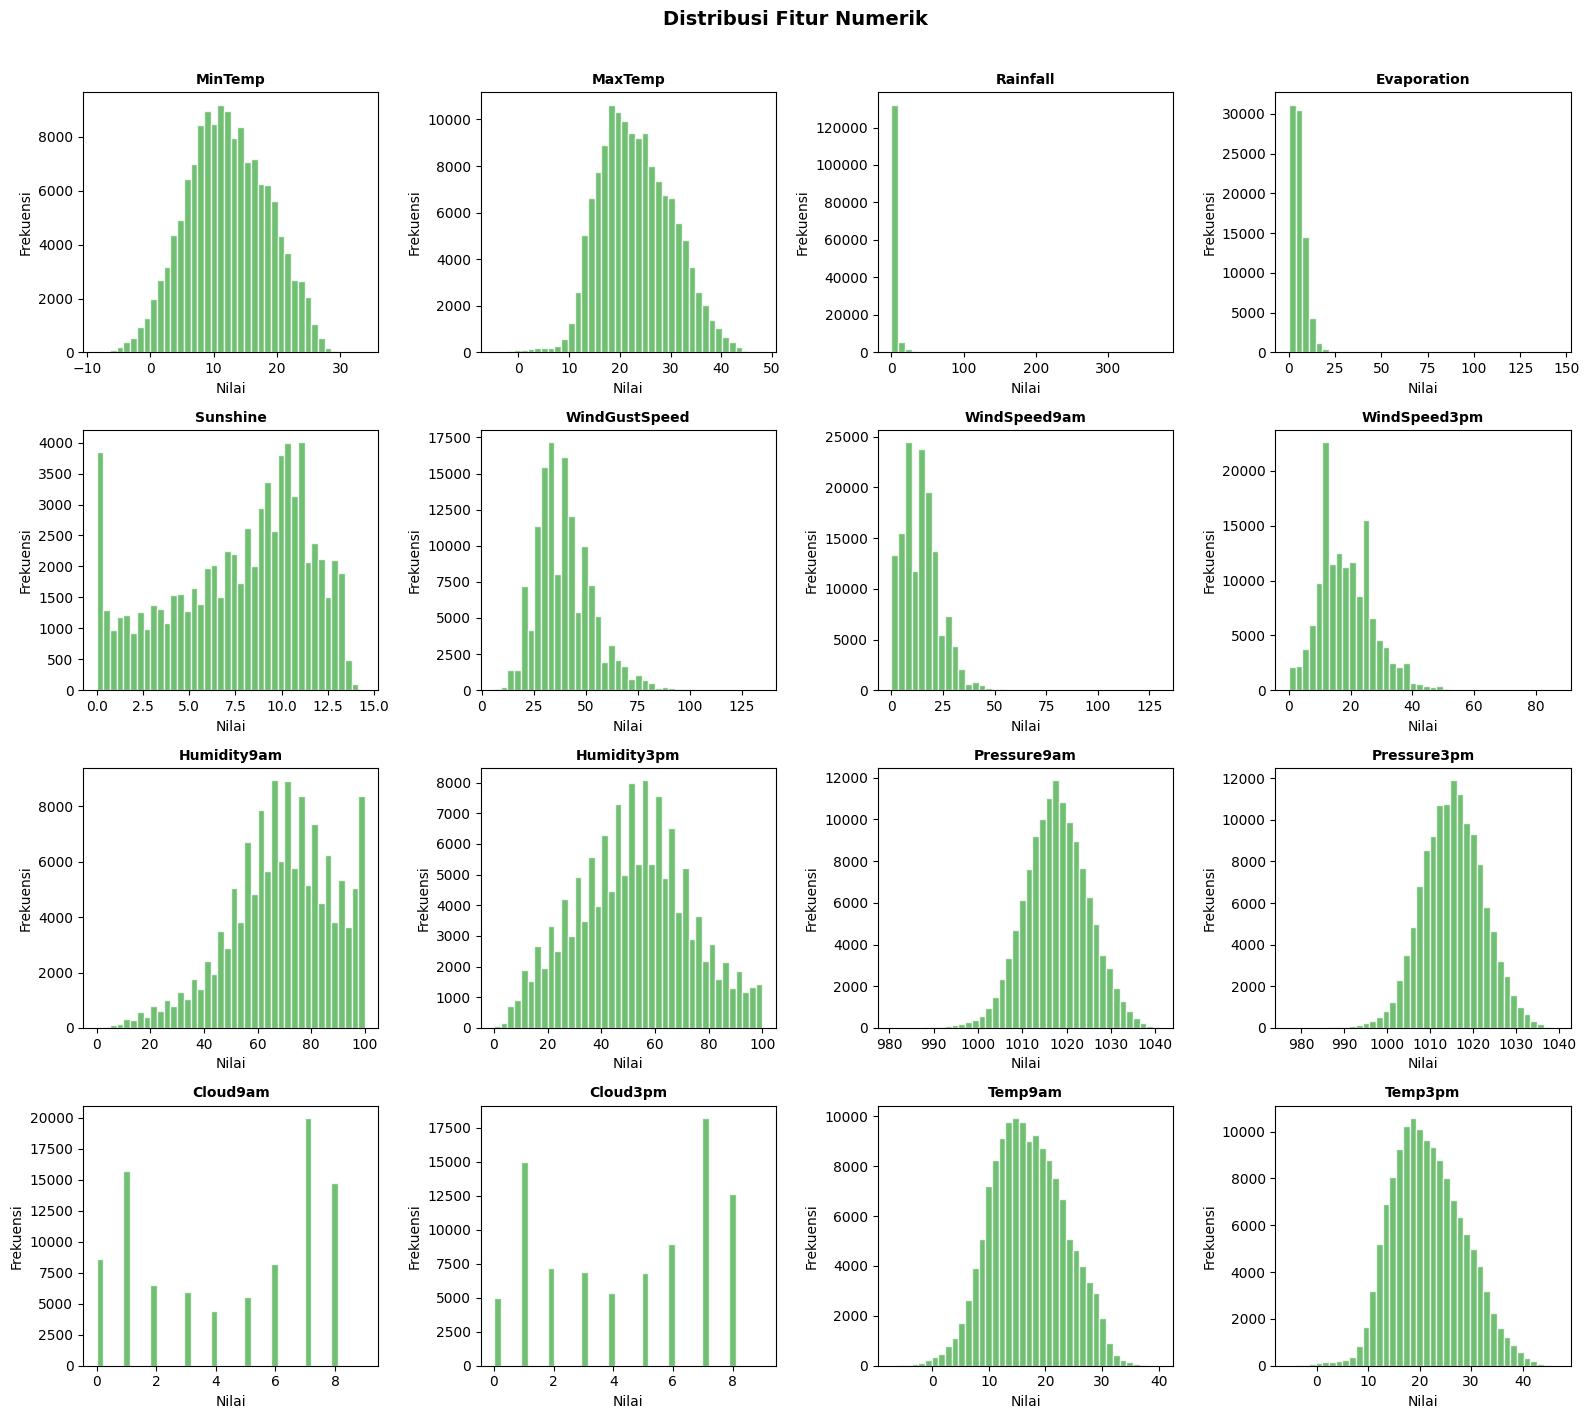

In [7]:
# Pilih kolom numerik (kecuali target)
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "RainTomorrow"]

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_raw[col].dropna(), bins=40, color="#4CAF50", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

# Sembunyikan axes kosong
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

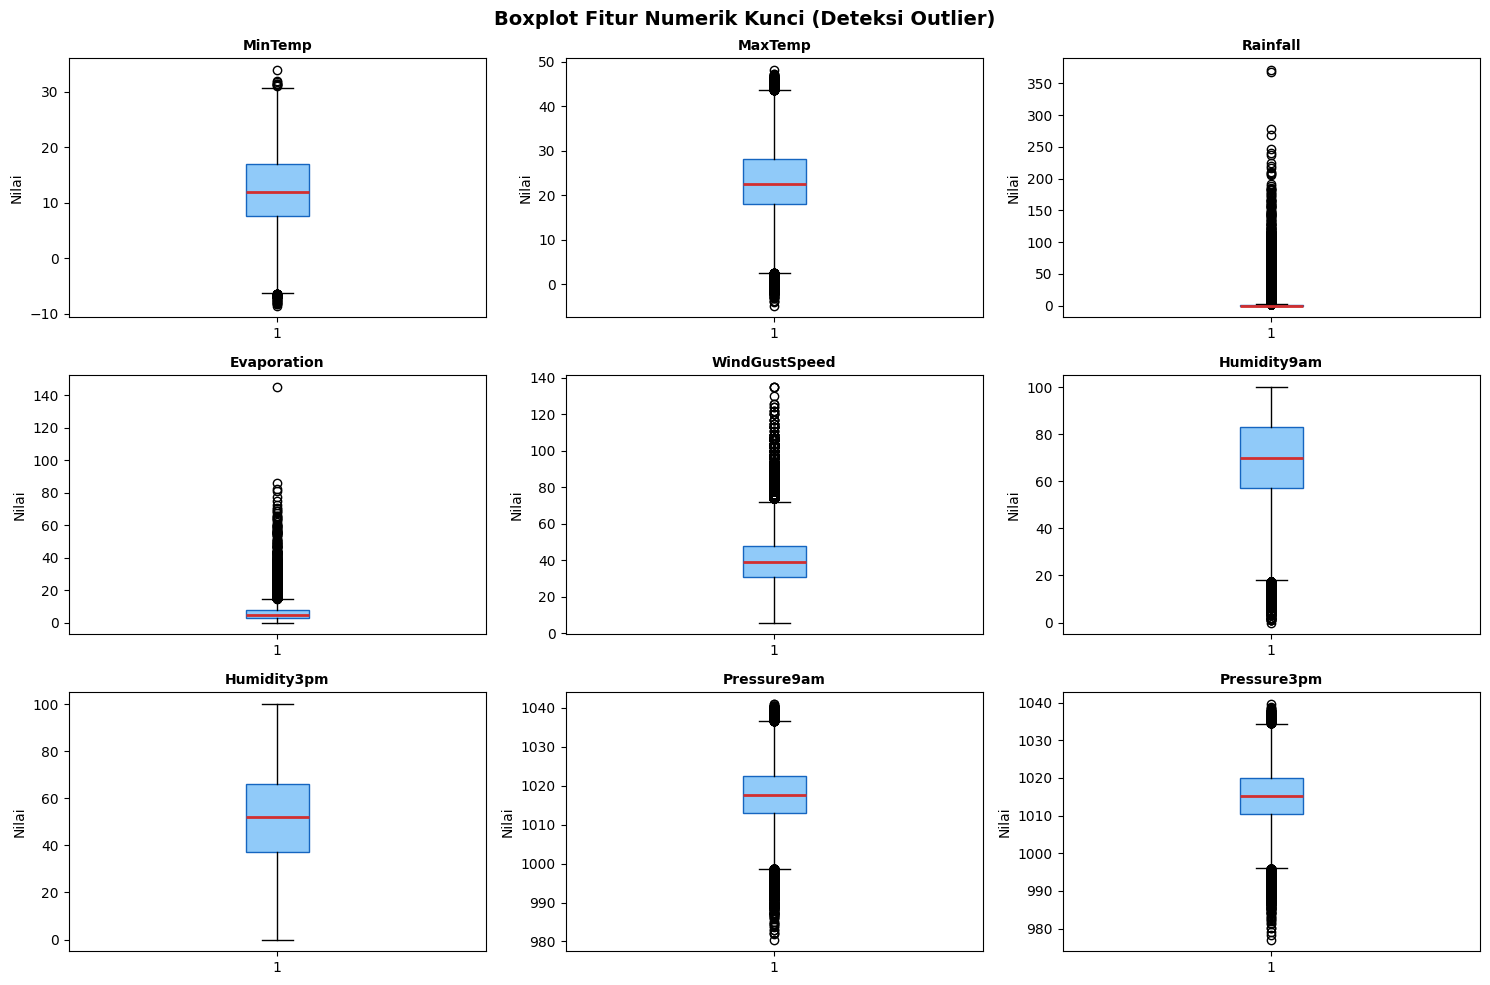

In [8]:
# Boxplot untuk mendeteksi outlier
key_cols = ["MinTemp", "MaxTemp", "Rainfall", "Evaporation",
            "WindGustSpeed", "Humidity9am", "Humidity3pm",
            "Pressure9am", "Pressure3pm"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].boxplot(df_raw[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#90CAF9", color="#1565C0"),
                    medianprops=dict(color="#D32F2F", linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Nilai")

plt.suptitle("Boxplot Fitur Numerik Kunci (Deteksi Outlier)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

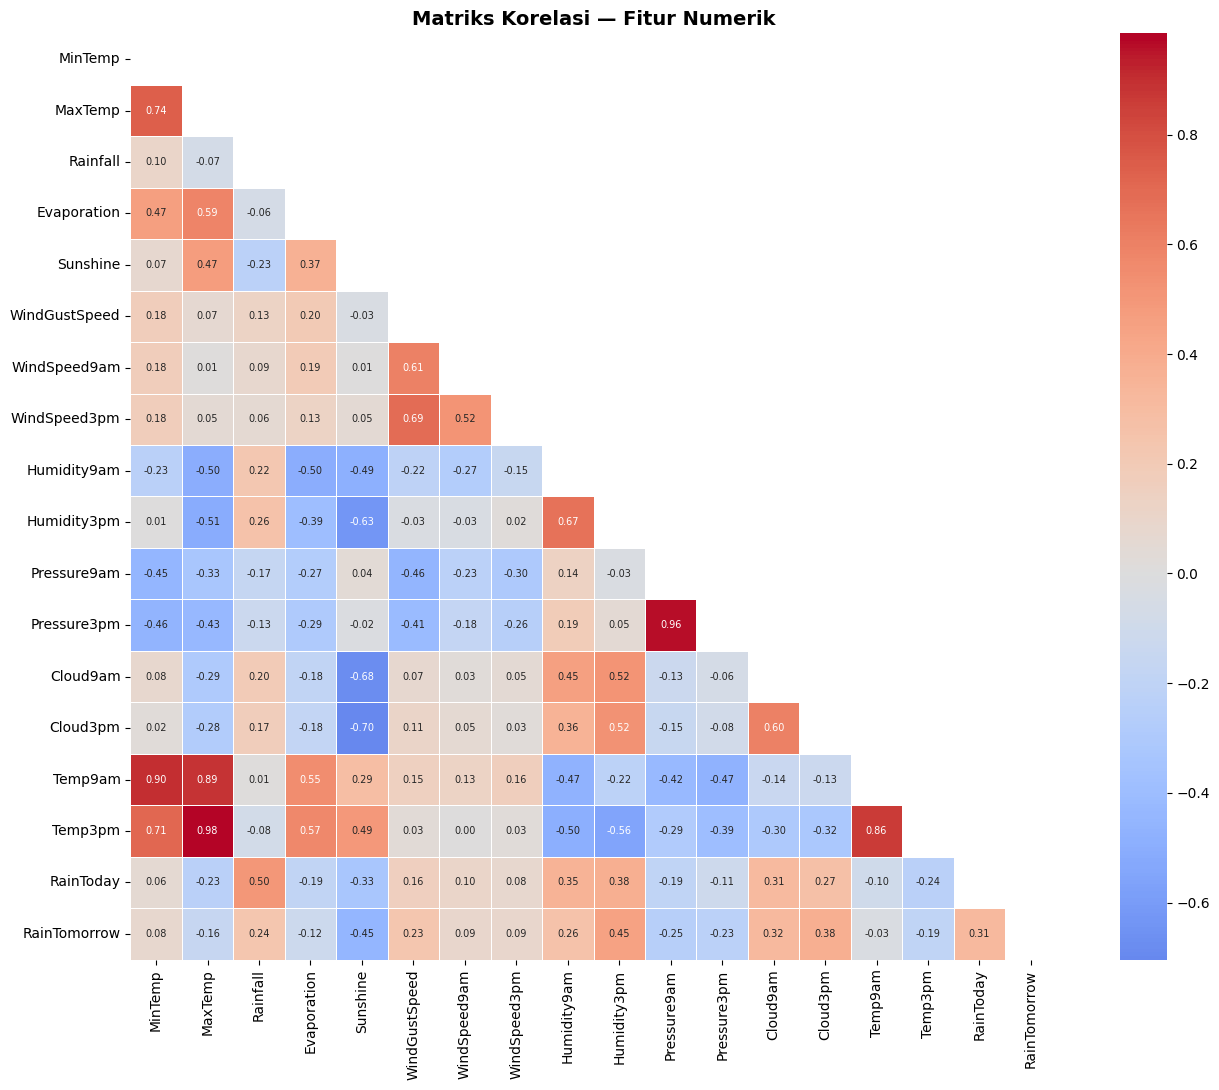

In [9]:
# Encode target sementara untuk korelasi
df_corr = df_raw.copy()
df_corr["RainTomorrow"] = df_corr["RainTomorrow"].map({"Yes": 1, "No": 0})
df_corr["RainToday"] = df_corr["RainToday"].map({"Yes": 1, "No": 0})

corr_matrix = df_corr[num_cols + ["RainToday", "RainTomorrow"]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, ax=ax,
            annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Matriks Korelasi — Fitur Numerik", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

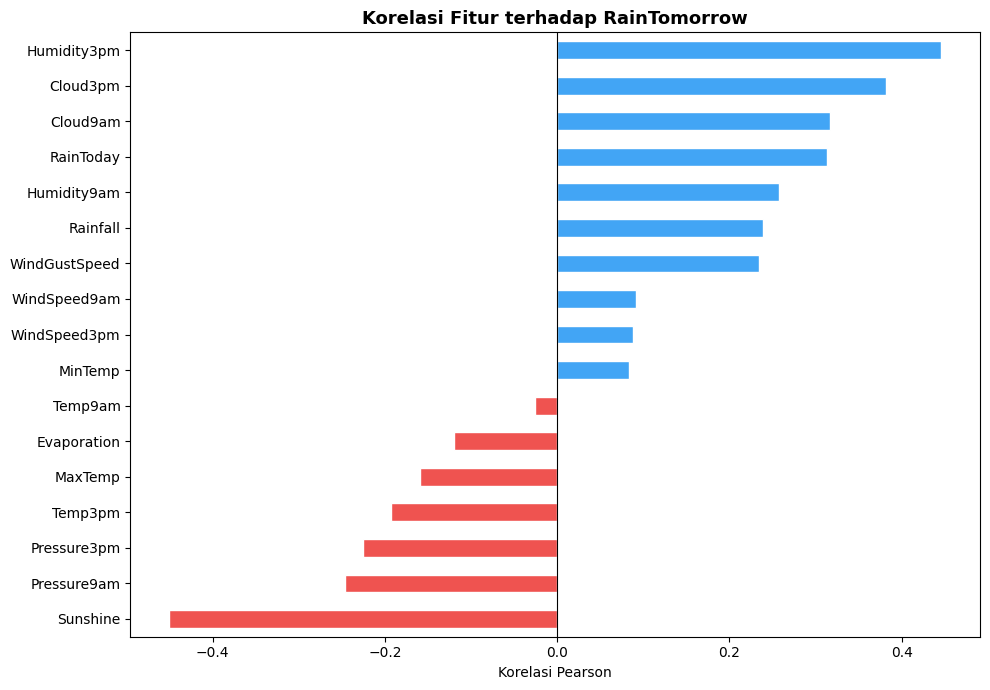

In [10]:
# Korelasi fitur terhadap target
corr_target = corr_matrix["RainTomorrow"].drop("RainTomorrow").sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#EF5350" if v < 0 else "#42A5F5" for v in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Korelasi Fitur terhadap RainTomorrow", fontsize=13, fontweight="bold")
ax.set_xlabel("Korelasi Pearson")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_114124/2477945617.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_raw.select_dtypes(include="object").columns.tolist()


Kolom kategorikal: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


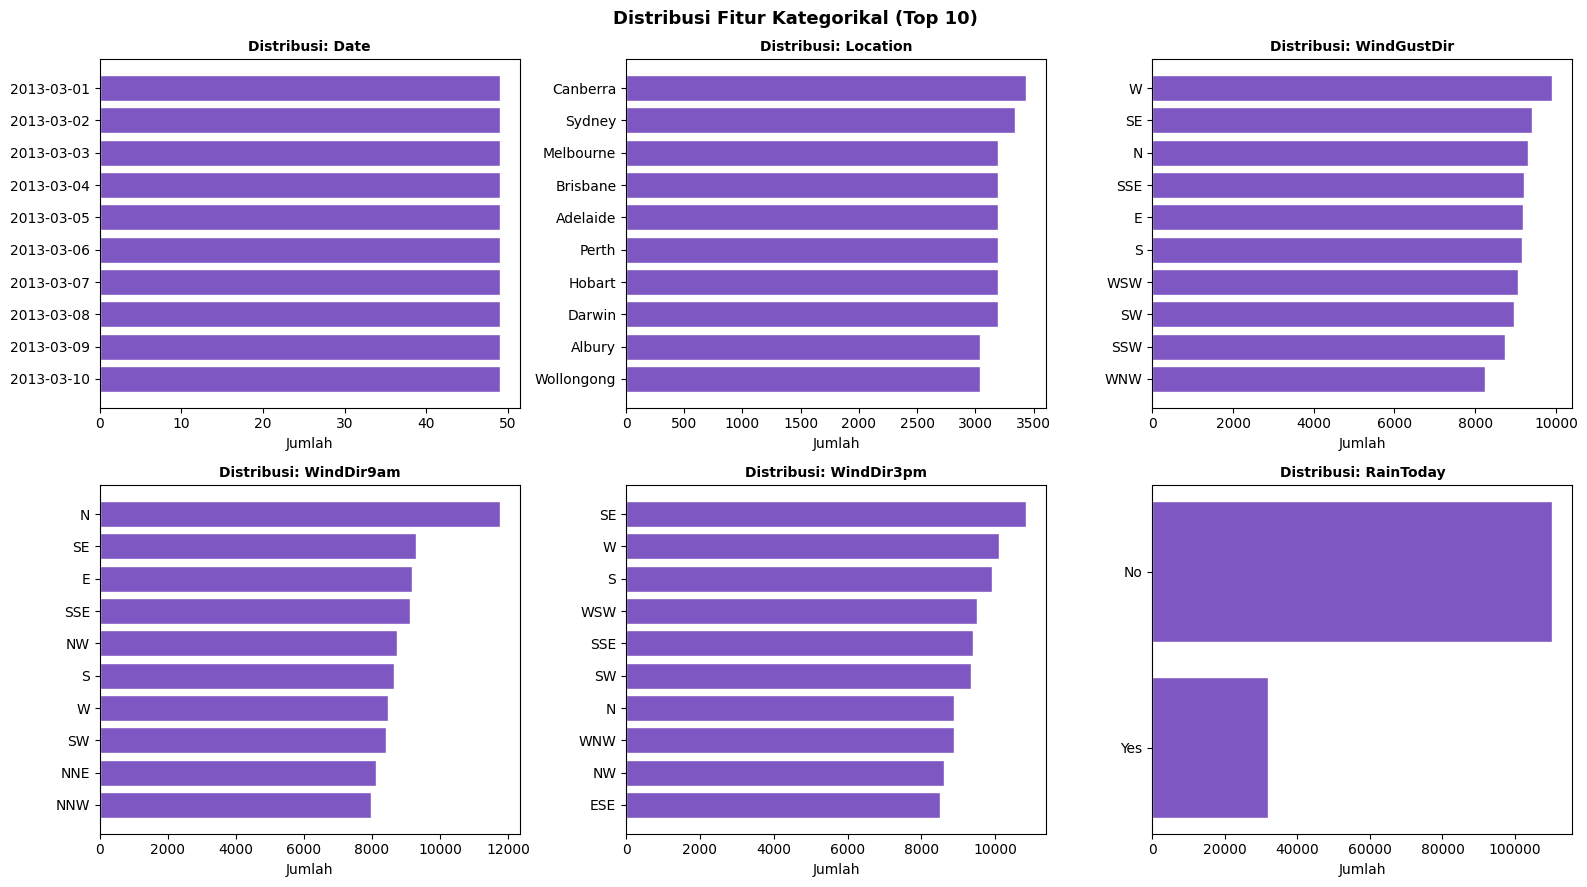

In [11]:
# Distribusi kolom kategorikal
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != "RainTomorrow"]
print(f"Kolom kategorikal: {cat_cols}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    top_vals = df_raw[col].value_counts().head(10)
    axes[i].barh(top_vals.index.astype(str), top_vals.values,
                 color="#7E57C2", edgecolor="white")
    axes[i].set_title(f"Distribusi: {col}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Jumlah")
    axes[i].invert_yaxis()

plt.suptitle("Distribusi Fitur Kategorikal (Top 10)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
df = df_raw.copy()

# Ekstrak Year, Month, Day dari kolom Date
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df.drop(columns=["Date"], inplace=True)

print("Fitur tanggal berhasil diekstrak.")
print(f"Kolom baru  : Year, Month, Day")
print(f"Shape       : {df.shape}")
df[["Year", "Month", "Day"]].head()

Fitur tanggal berhasil diekstrak.
Kolom baru  : Year, Month, Day
Shape       : (145460, 25)


,Year,Month,Day
0,2008,12,1
1,2008,12,2
2,2008,12,3
3,2008,12,4
4,2008,12,5


In [16]:
# Kolom numerik -> median | Kolom kategorikal -> modus
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

before_na = df.isnull().sum().sum()

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

after_na = df.isnull().sum().sum()

print(f"Missing values berhasil ditangani.")
print(f"Sebelum : {before_na:,}")
print(f"Sesudah : {after_na:,}")

Missing values berhasil ditangani.
Sebelum : 343,248
Sesudah : 343,248


/tmp/ipykernel_114124/3454602511.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()
/tmp/ipykernel_114124/3454602511.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [17]:
# Binary encoding untuk RainToday dan RainTomorrow
binary_map = {"Yes": 1, "No": 0}
df["RainToday"]    = df["RainToday"].map(binary_map)
df["RainTomorrow"] = df["RainTomorrow"].map(binary_map)

# Label Encoding untuk kolom kategorikal lainnya
cat_remaining = df.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()

for col in cat_remaining:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Encoding selesai.")
print(f"Binary encoded : RainToday, RainTomorrow")
print(f"Label encoded  : {cat_remaining}")
print(f"Shape           : {df.shape}")
print(f"Tipe data setelah encoding :")
print(df.dtypes.value_counts())

Encoding selesai.
Binary encoded : RainToday, RainTomorrow
Label encoded  : ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
Shape           : (145460, 25)
Tipe data setelah encoding :
float64    18
int64       4
int32       3
Name: count, dtype: int64


/tmp/ipykernel_114124/369671383.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_remaining = df.select_dtypes(include="object").columns.tolist()


In [18]:
# Hapus outlier menggunakan IQR pada fitur numerik (kecuali target)
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != "RainTomorrow"]

before_rows = len(df)

for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

after_rows = len(df)
df.reset_index(drop=True, inplace=True)

print(f"Outlier berhasil dihapus.")
print(f"Baris sebelum : {before_rows:,}")
print(f"Baris sesudah : {after_rows:,}")
print(f"Dihapus       : {before_rows - after_rows:,} baris ({(before_rows - after_rows)/before_rows*100:.1f}%)")

Outlier berhasil dihapus.
Baris sebelum : 145,460
Baris sesudah : 41,074
Dihapus       : 104,386 baris (71.8%)


In [19]:
# Scaling semua fitur (kecuali target)
X_cols = [c for c in df.columns if c != "RainTomorrow"]
scaler = StandardScaler()
df[X_cols] = scaler.fit_transform(df[X_cols])

print("Feature scaling selesai menggunakan StandardScaler.")
print(f"Jumlah fitur yang di-scale : {len(X_cols)}")
print("\nStatistik setelah scaling (harusnya mean≈0, std≈1):")
df[X_cols[:5]].describe().loc[["mean", "std"]].round(4)

Feature scaling selesai menggunakan StandardScaler.
Jumlah fitur yang di-scale : 24

Statistik setelah scaling (harusnya mean≈0, std≈1):


,Location,MinTemp,MaxTemp,Rainfall,Evaporation
mean,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


In [ ]:
# Memisahkan fitur dan target
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

# Split 80:20 dengan stratify untuk menjaga proporsi kelas
valid_idx = y.notna()
X = X.loc[valid_idx]
y = y.loc[valid_idx].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print("Dataset berhasil dibagi:")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nProporsi kelas train:")
print((y_train.value_counts(normalize=True) * 100).round(1))

Dataset berhasil dibagi:
X_train : (32798, 24)
X_test  : (8200, 24)
y_train : (32798,)
y_test  : (8200,)

Proporsi kelas train:
RainTomorrow
0    85.8
1    14.2
Name: proportion, dtype: float64


In [22]:
# Simpan dataset yang sudah diproses
OUTPUT_DIR = "weatherAUS_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv",   index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv",   index=False)
df.to_csv(f"{OUTPUT_DIR}/weatherAUS_preprocessing.csv", index=False)

print(f"Dataset tersimpan di folder '{OUTPUT_DIR}':")
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    print(f"{f:<45} {size:.1f} KB")

Dataset tersimpan di folder 'weatherAUS_preprocessing':
X_train.csv                                   14531.1 KB
y_test.csv                                    16.0 KB
weatherAUS_preprocessing.csv                  18357.2 KB
y_train.csv                                   64.1 KB
X_test.csv                                    3632.5 KB
